**Here, I wanted to plot each of the greeks myself as a 3d surfance to try to understand the relationships between each greek and strike/time**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from src.greeks import delta, gamma, theta, vega, rho

In [2]:
def compute_greek_surface(S_grid, T_grid, K, r, sigma, metric='gamma', option_type='call'):

    if metric == 'gamma':
        return gamma(S=S_grid, T=T_grid, r=r, K=K, sigma=sigma)
    elif metric == 'vega':
        return vega(S=S_grid, T=T_grid, r=r, K=K, sigma=sigma)
    elif metric == 'theta':
        return theta(S=S_grid, T=T_grid, r=r, K=K, sigma=sigma, option_type=option_type)
    elif metric == 'delta':
        return delta(S=S_grid, T=T_grid, r=r, K=K, sigma=sigma, option_type=option_type)
    else:
        raise ValueError('Unknown metric')

In [3]:
def build_grid(S_min, S_max, T_min, T_max, n=100):
    S = np.linspace(S_min, S_max, n)
    T = np.linspace(T_min, T_max, n)

    S_grid, T_grid = np.meshgrid(S, T)
    return S_grid, T_grid

In [4]:
def plot_surface(S_grid, T_grid, Z, title, zlabel):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(S_grid, T_grid, Z, cmap="viridis", edgecolor="none")

    ax.set_title(title)
    ax.set_xlabel("Spot (S)")
    ax.set_ylabel("Time to Expiry (T)")
    ax.set_zlabel(zlabel)

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    plt.show()

In [5]:
K = 100
r = 0.02
sigma = 0.2

S_grid, T_grid = build_grid(50, 150, 0.01, 2.0, n=150)

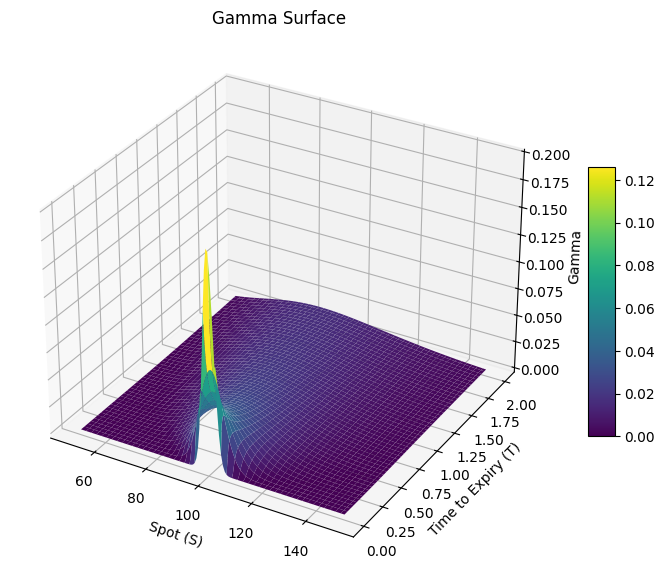

In [6]:
Z_gamma = compute_greek_surface(S_grid, T_grid, K, r, sigma, metric='gamma')

plot_surface(S_grid, T_grid, Z_gamma, 'Gamma Surface', 'Gamma')

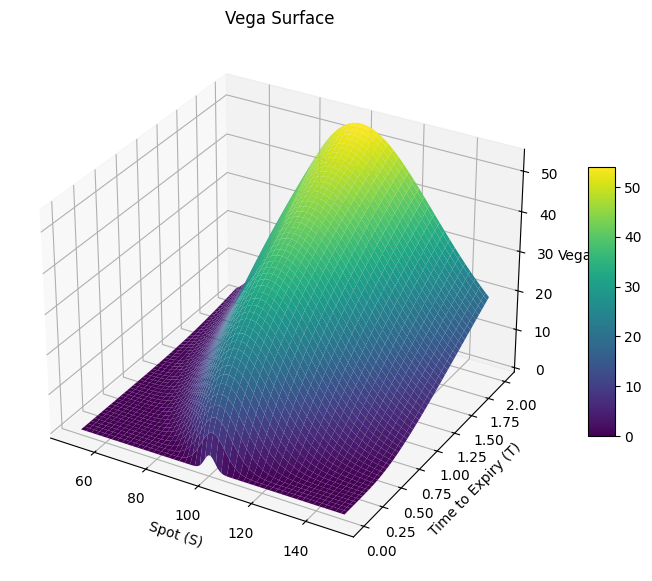

In [7]:
Z_vega = compute_greek_surface(S_grid, T_grid, K, r, sigma, metric='vega')

plot_surface(S_grid, T_grid, Z_vega, 'Vega Surface', 'Vega')

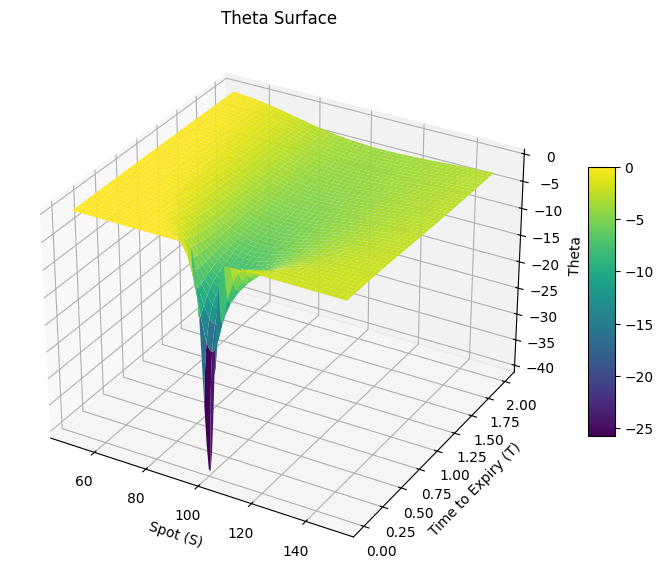

In [8]:
Z_theta = compute_greek_surface(S_grid, T_grid, K, r, sigma, metric='theta')

plot_surface(S_grid, T_grid, Z_theta, 'Theta Surface', 'Theta')

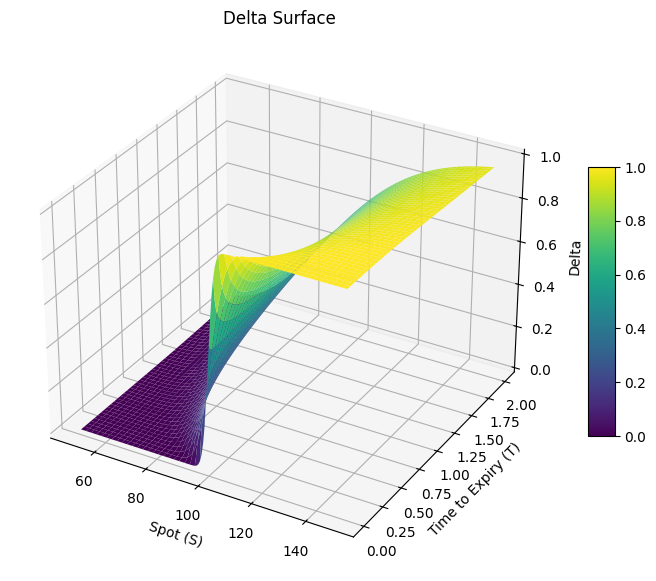

In [9]:
Z_delta = compute_greek_surface(S_grid, T_grid, K, r, sigma, metric='delta')

plot_surface(S_grid, T_grid, Z_delta, 'Delta Surface', 'Delta')

**I also wanted to plot important Greek relationships to understand how they related**

In [13]:
def plot_surface_colored(S_grid, T_grid, Z, C, title, zlabel, cmap='viridis'):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        S_grid,
        T_grid,
        Z,
        facecolors=plt.cm.viridis((C - C.min()) / (C.max() - C.min())),
        linewidth=0,
        antialiased=False,
        shade=False
    )

    ax.set_title(title)
    ax.set_xlabel('Spot')
    ax.set_ylabel('Time to Expiry')
    ax.set_zlabel(zlabel)

    m = plt.cm.ScalarMappable(cmap='viridis')
    m.set_array(C)
    fig.colorbar(m, ax=ax, shrink=0.5)

    plt.show()

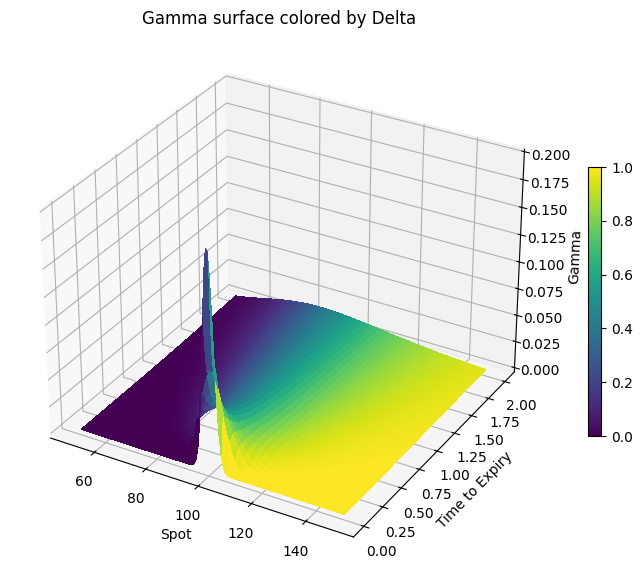

In [14]:
# Plot gamma surface colored by delta to examine relationship here

plot_surface_colored(
    S_grid, T_grid,
    Z_gamma,
    Z_delta,
    'Gamma surface colored by Delta',
    'Gamma'
)

Buying an option means being long $\Gamma$. Therefore, your $\Delta$ accelerates in your favor as the underlying price moves.  

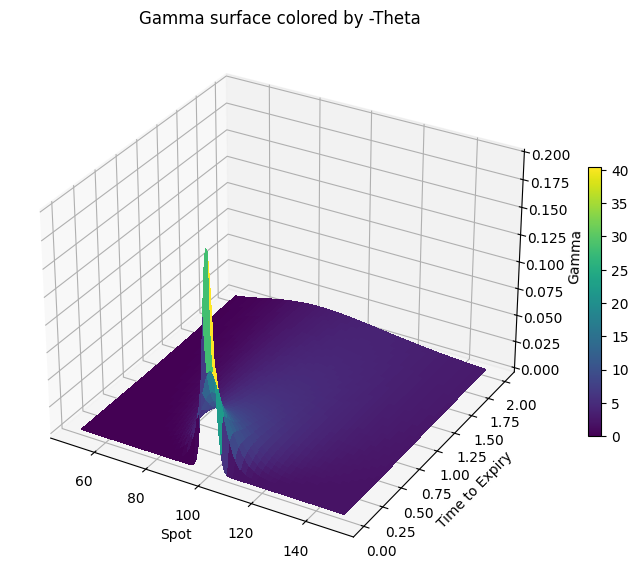

In [17]:
# Plot gamma surface colored by theta
plot_surface_colored(
    S_grid, T_grid,
    Z_gamma,
    -Z_theta,
    'Gamma surface colored by -Theta',
    'Gamma'
)

Based on the coloring, you can see that $\Theta$ (price decay) accelerates aggressively as the option's time to expiry decreases. Based on the coloring, you can also see the inverse relationship that $\Gamma$ has with $\Theta$, highlighting the tension that exists where you might benefit from acceleration if the underlying moves but also pay a premium in time decay.

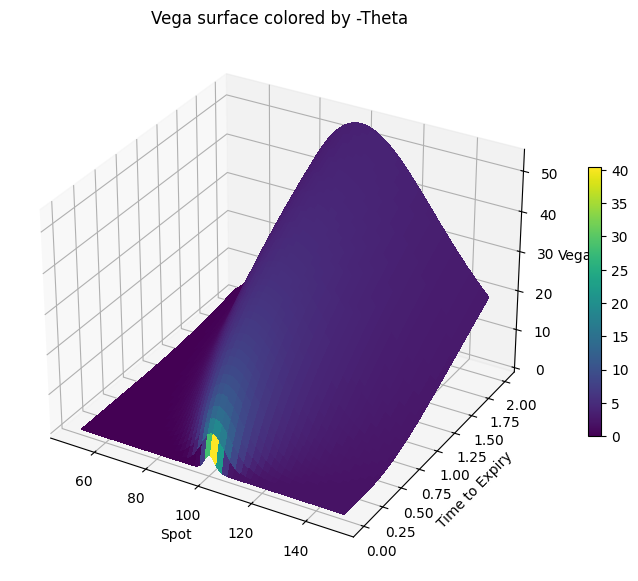

In [18]:
# Plot vega surface colored by theta
plot_surface_colored(
    S_grid, T_grid,
    Z_vega,
    -Z_theta,
    'Vega surface colored by -Theta',
    'Vega'
)

$\nu$ and $\Theta$ are inversely related drivers of the extrinsic value of an option. For longer time possessions, you can see $\nu$ is higher while $\Theta$ is lower -- i.e. you expose yourself to higher voliltility but less price decay. Conversely, in the short term, you experience greater price decay but are less susceptible to increases in volatility.